# Quantum Gates (Qiskit) — Descriptions + Examples

This notebook shows common quantum gates with **(1) a short explanation** and **(2) a runnable Qiskit example**.

**Notes**
- A *quantum gate* is typically a **unitary** operation (reversible).
- Many **phase gates** (Z, S, T, P, Rz, CZ, …) do *not* change measurement probabilities in the Z-basis, but they *do* change the **statevector phase**. That’s why we print the statevector before measuring.
- For each example we: build a circuit (without measurement) → print the statevector → measure and simulate → plot a histogram.

In [30]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from IPython.display import display
import numpy as np
import warnings
warnings.filterwarnings('ignore')

simulator = AerSimulator()

In [31]:
def statevector_of(qc: QuantumCircuit) -> Statevector:
    """Return statevector for the circuit (ignoring final measurements if present)."""
    try:
        qc_nom = qc.remove_final_measurements(inplace=False)
    except Exception:
        qc_nom = qc.copy()
    return Statevector.from_instruction(qc_nom)


def counts_from_circuit(qc: QuantumCircuit, shots: int = 1024):
    """Measure all qubits and return (measured_circuit, counts)."""
    qc_m = qc.copy()
    qc_m.measure_all()
    tqc = transpile(qc_m, simulator)
    result = simulator.run(tqc, shots=shots).result()
    return qc_m, result.get_counts()


def demo(qc: QuantumCircuit, title: str, shots: int = 2000, show_statevector: bool = True):
    print(f"\n=== {title} ===")
    if show_statevector:
        print('Statevector (before measurement):')
        print(statevector_of(qc))
    display(qc.draw('mpl'))
    qc_m, counts = counts_from_circuit(qc, shots=shots)
    print('Counts:', counts)
    display(qc_m.draw('mpl'))
    display(plot_histogram(counts))
    return counts

## 1-qubit gates

### Identity (I)
Does nothing: |0⟩ → |0⟩, |1⟩ → |1⟩.


=== I gate ===
Statevector (before measurement):
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


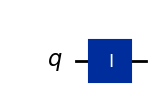

Counts: {'0': 2000}


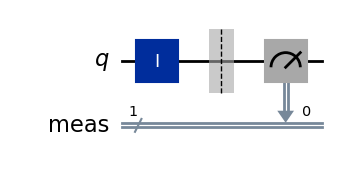

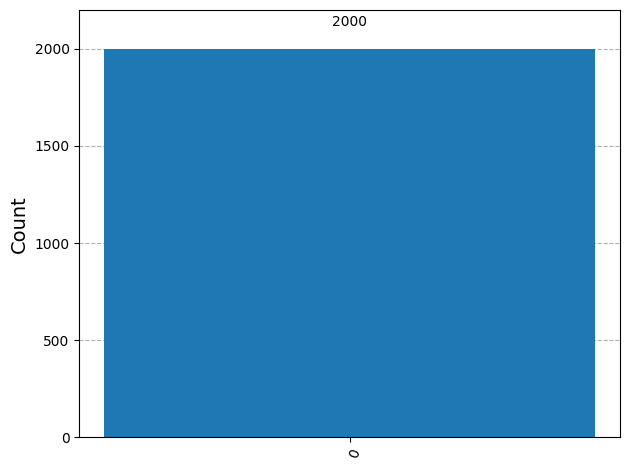

{'0': 2000}

In [32]:
qc = QuantumCircuit(1, name='I')
qc.id(0)
demo(qc, 'I gate')

### Pauli-X (NOT)
Bit-flip: |0⟩ ↔ |1⟩.


=== X gate ===
Statevector (before measurement):
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


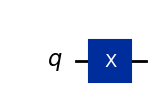

Counts: {'1': 2000}


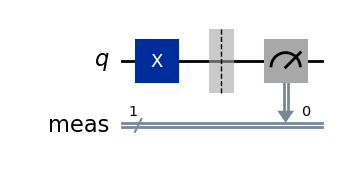

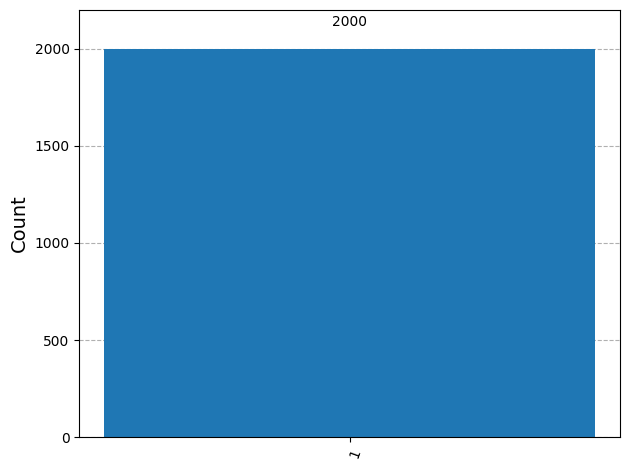

{'1': 2000}

In [33]:
qc = QuantumCircuit(1, name='X')
qc.x(0)
demo(qc, 'X gate')

### Pauli-Y
Bit-flip + phase: Y = iXZ. It flips |0⟩ ↔ |1⟩ with a relative phase.


=== Y gate ===
Statevector (before measurement):
Statevector([0.+0.j, 0.+1.j],
            dims=(2,))


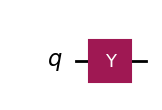

Counts: {'1': 2000}


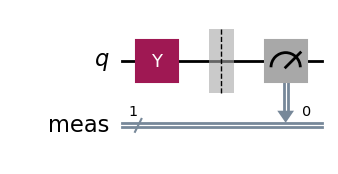

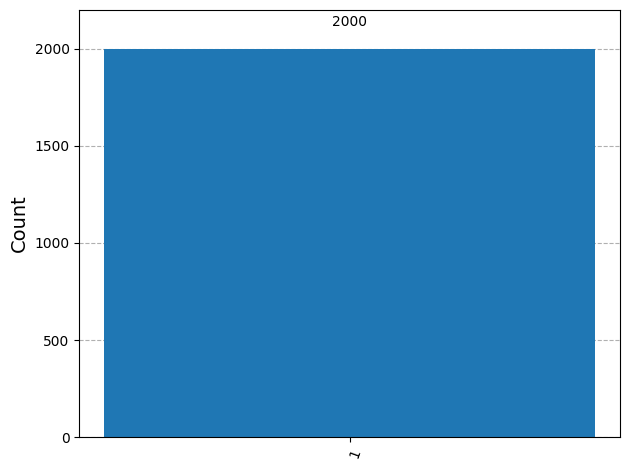

{'1': 2000}

In [34]:
qc = QuantumCircuit(1, name='Y')
qc.y(0)
demo(qc, 'Y gate')

### Pauli-Z
Phase-flip: Z|0⟩ = |0⟩, Z|1⟩ = −|1⟩. Measurement in the Z-basis looks unchanged unless you create superposition/interference.


=== Z gate acting on |1> (phase becomes -1) ===
Statevector (before measurement):
Statevector([ 0.+0.j, -1.+0.j],
            dims=(2,))


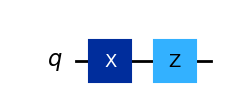

Counts: {'1': 2000}


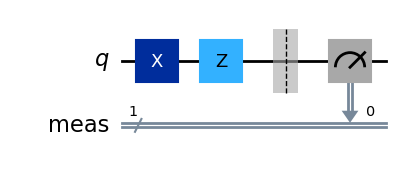

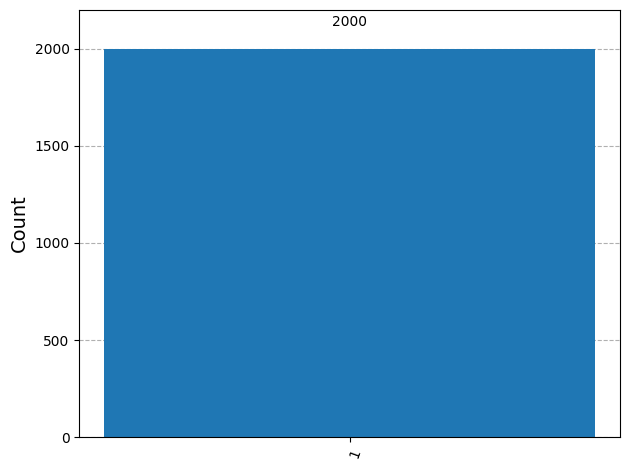

{'1': 2000}

In [35]:
qc = QuantumCircuit(1, name='Z')
qc.x(0)  # prepare |1>
qc.z(0)
demo(qc, 'Z gate acting on |1> (phase becomes -1)')

### Hadamard (H)
Creates superposition: H|0⟩ = |+⟩ = (|0⟩ + |1⟩)/√2.


=== H gate (expect ~50/50) ===
Statevector (before measurement):
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


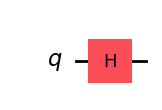

Counts: {'1': 992, '0': 1008}


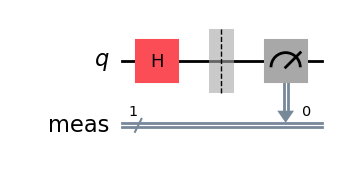

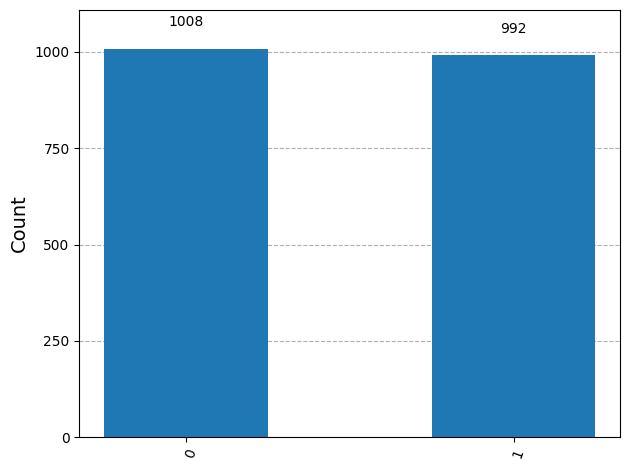

{'1': 992, '0': 1008}

In [36]:
qc = QuantumCircuit(1, name='H')
qc.h(0)
demo(qc, 'H gate (expect ~50/50)')

### Phase gates: S, S†, T, T†
These are Z-axis phase rotations:
- S = Rz(π/2)
- T = Rz(π/4)
They change **relative phase**, which is visible in the statevector (and in interference), not necessarily in Z-basis counts.


=== S gate on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


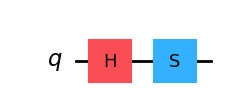

Counts: {'0': 1013, '1': 987}


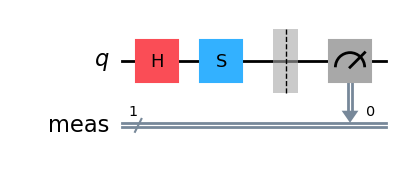

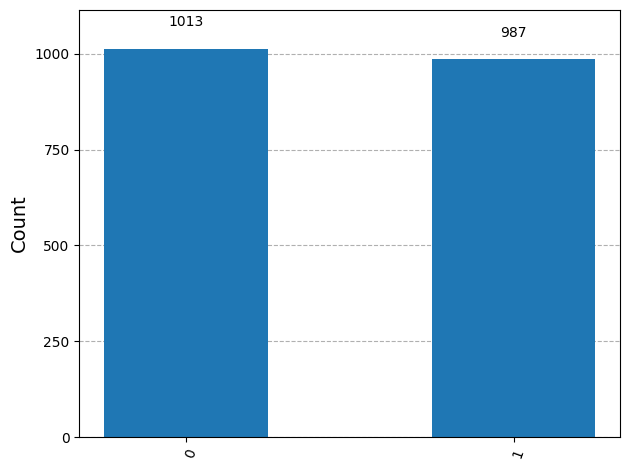


=== T gate on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


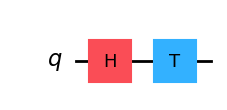

Counts: {'1': 963, '0': 1037}


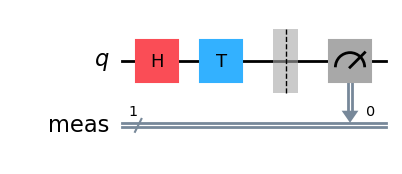

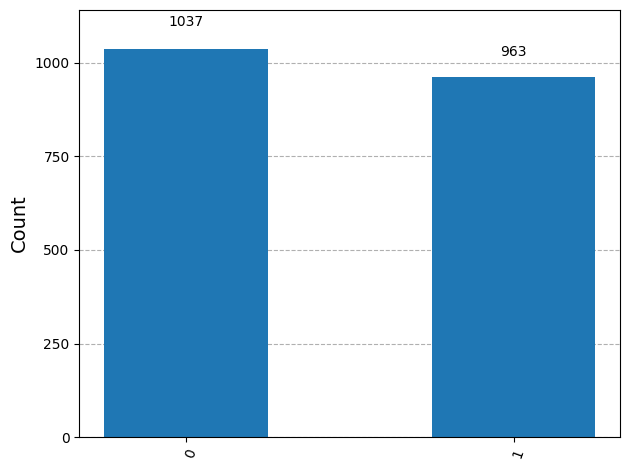


=== S† (Sdg) on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


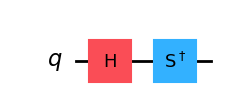

Counts: {'0': 1032, '1': 968}


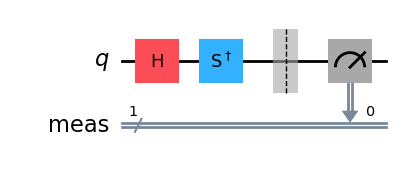

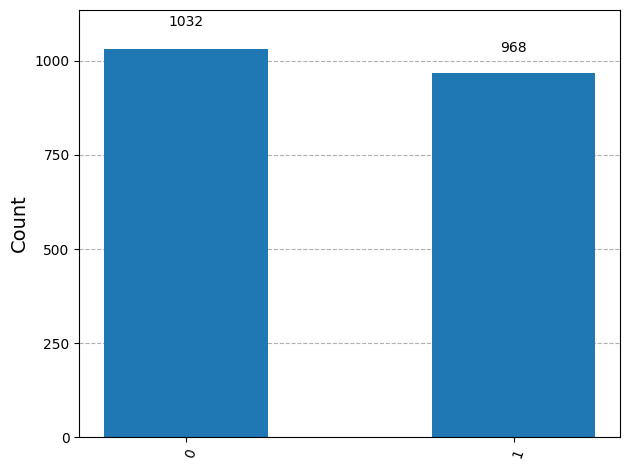


=== T† (Tdg) on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j , 0.5       -0.5j],
            dims=(2,))


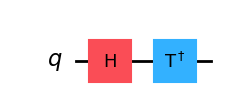

Counts: {'0': 1019, '1': 981}


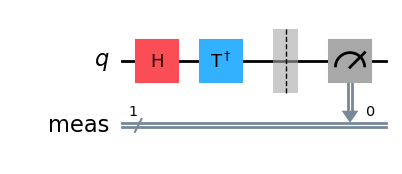

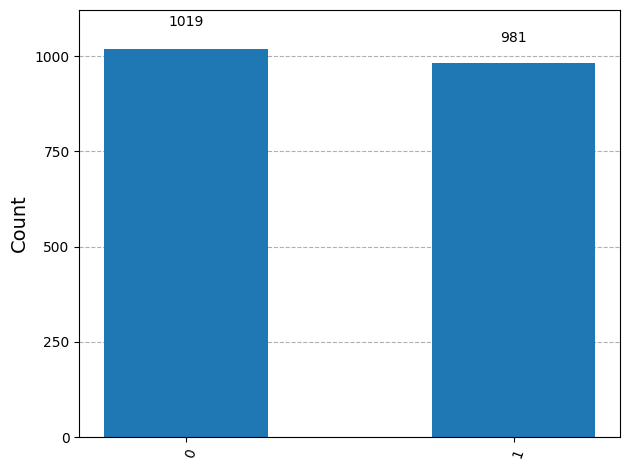

{'0': 1019, '1': 981}

In [37]:
qc = QuantumCircuit(1, name='S on |+>')
qc.h(0)
qc.s(0)
demo(qc, 'S gate on |+>')

qc = QuantumCircuit(1, name='T on |+>')
qc.h(0)
qc.t(0)
demo(qc, 'T gate on |+>')

qc = QuantumCircuit(1, name='Sdg on |+>')
qc.h(0)
qc.sdg(0)
demo(qc, 'S† (Sdg) on |+>')

qc = QuantumCircuit(1, name='Tdg on |+>')
qc.h(0)
qc.tdg(0)
demo(qc, 'T† (Tdg) on |+>')

### Rotation gates: Rx, Ry, Rz
Continuous rotations around Bloch-sphere axes. Examples below use θ = π/2.


=== Rx(pi/2) ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


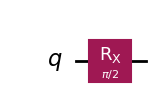

Counts: {'0': 1018, '1': 982}


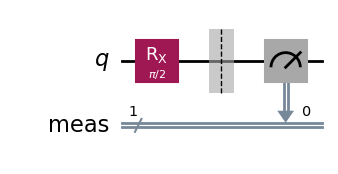

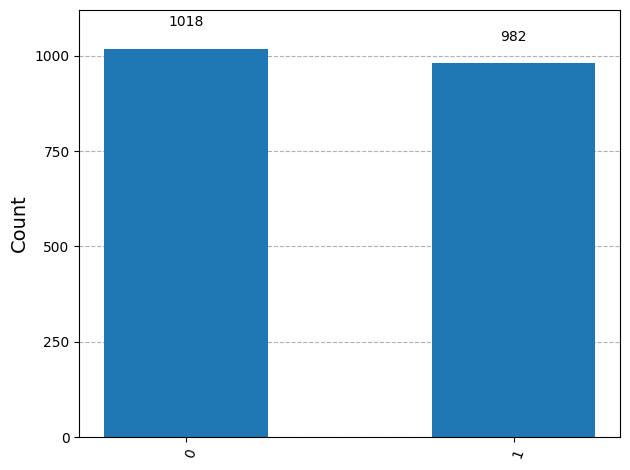


=== Ry(pi/2) ===
Statevector (before measurement):
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


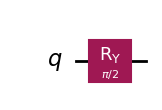

Counts: {'0': 989, '1': 1011}


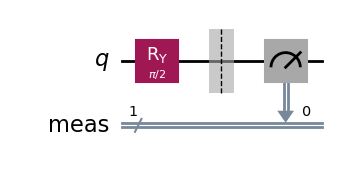

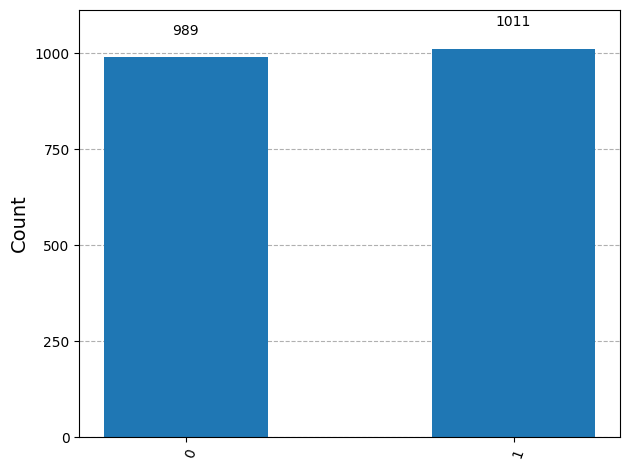


=== Rz(pi/2) on |+> ===
Statevector (before measurement):
Statevector([0.5-0.5j, 0.5+0.5j],
            dims=(2,))


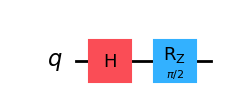

Counts: {'1': 968, '0': 1032}


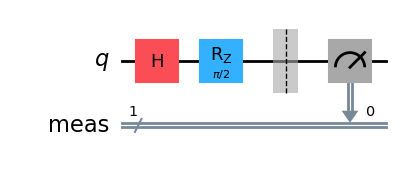

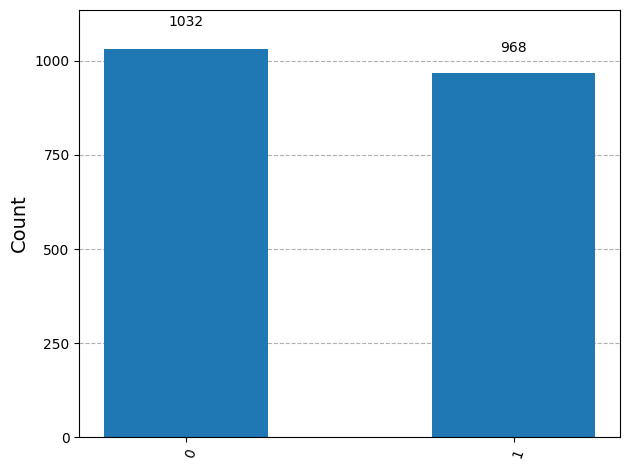

{'1': 968, '0': 1032}

In [38]:
theta = np.pi / 2

qc = QuantumCircuit(1, name='Rx')
qc.rx(theta, 0)
demo(qc, 'Rx(pi/2)')

qc = QuantumCircuit(1, name='Ry')
qc.ry(theta, 0)
demo(qc, 'Ry(pi/2)')

qc = QuantumCircuit(1, name='Rz')
qc.h(0)  # put into superposition so phase matters
qc.rz(theta, 0)
demo(qc, 'Rz(pi/2) on |+>')

### Phase shift (P) and general U gate
- `p(λ)` applies a phase e^{iλ} to |1⟩.
- `u(θ, φ, λ)` is a general single-qubit unitary used by Qiskit (sometimes called U3 in older literature).


=== P(pi/3) on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.35355339+0.61237244j],
            dims=(2,))


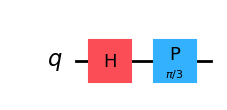

Counts: {'1': 973, '0': 1027}


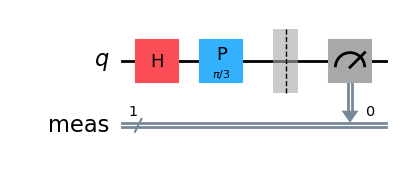

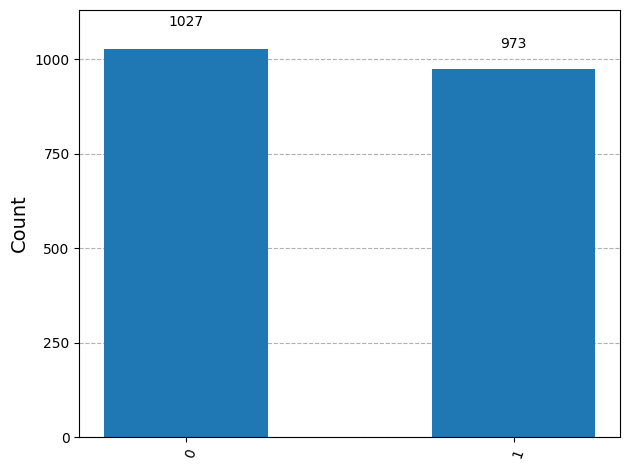


=== U(theta, phi, lambda) example ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.35355339+0.61237244j],
            dims=(2,))


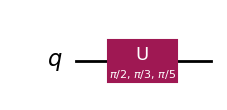

Counts: {'1': 1039, '0': 961}


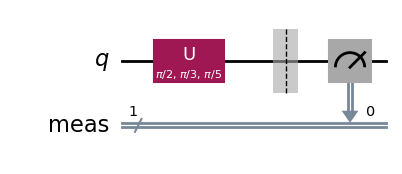

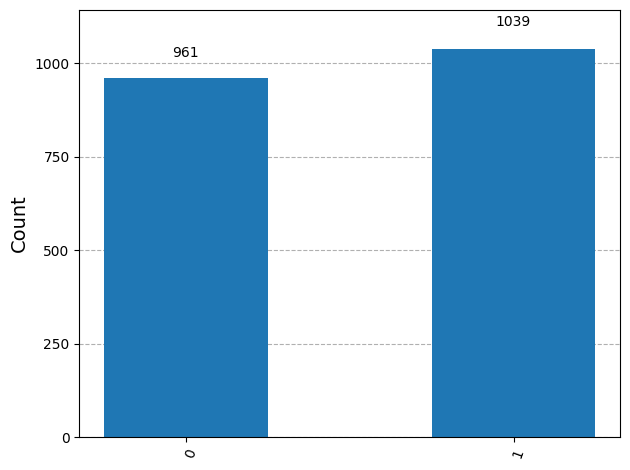

{'1': 1039, '0': 961}

In [39]:
qc = QuantumCircuit(1, name='P')
qc.h(0)
qc.p(np.pi/3, 0)
demo(qc, 'P(pi/3) on |+>')

qc = QuantumCircuit(1, name='U')
qc.u(np.pi/2, np.pi/3, np.pi/5, 0)
demo(qc, 'U(theta, phi, lambda) example')

## 2-qubit (and multi-qubit) gates

### Controlled-NOT (CX)
Flips the target when control is 1. Together with H, it can create entanglement (Bell state).


=== Bell state via H + CX (expect mostly 00 and 11) ===
Statevector (before measurement):
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


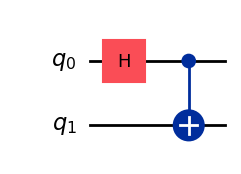

Counts: {'00': 1023, '11': 977}


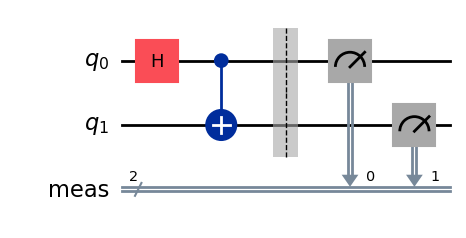

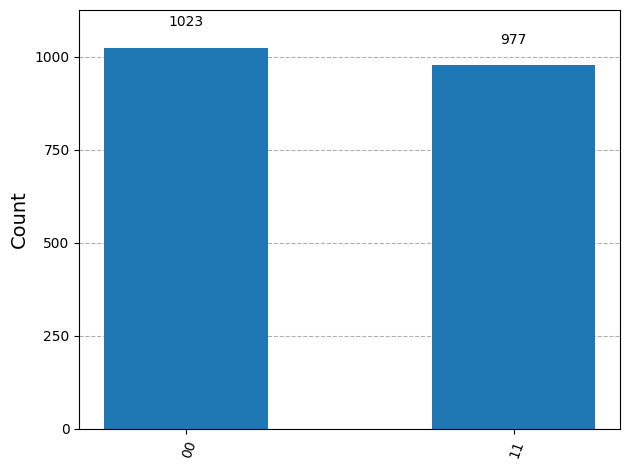

{'00': 1023, '11': 977}

In [40]:
qc = QuantumCircuit(2, name='Bell')
qc.h(0)
qc.cx(0, 1)
demo(qc, 'Bell state via H + CX (expect mostly 00 and 11)')

### Controlled-Z (CZ)
Applies a Z phase to the target when control is 1. It’s diagonal, so phase changes may not show up in Z-basis counts unless you interfere.


=== CZ on |++> (phase changes in statevector) ===
Statevector (before measurement):
Statevector([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))


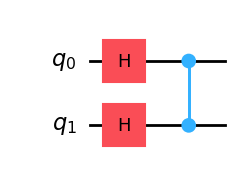

Counts: {'01': 528, '00': 513, '10': 479, '11': 480}


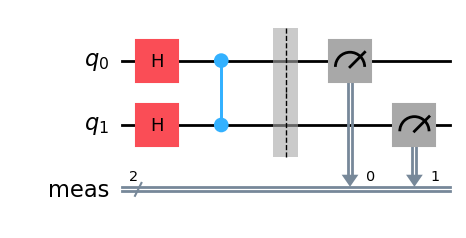

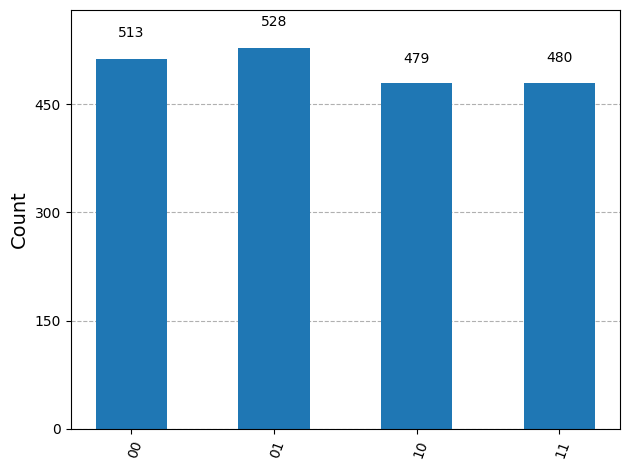

{'01': 528, '00': 513, '10': 479, '11': 480}

In [41]:
qc = QuantumCircuit(2, name='CZ')
qc.h(0)
qc.h(1)
qc.cz(0, 1)
demo(qc, 'CZ on |++> (phase changes in statevector)')

### Controlled-Y (CY) and Controlled-H (CH)
More controlled single-qubit gates.


=== CY with control prepared as |1> ===
Statevector (before measurement):
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+1.j],
            dims=(2, 2))


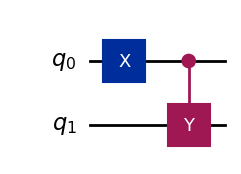

Counts: {'11': 2000}


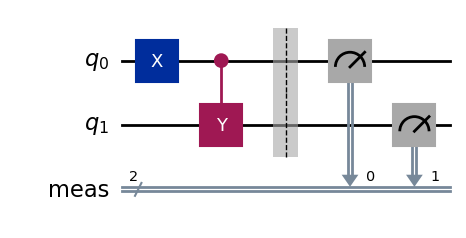

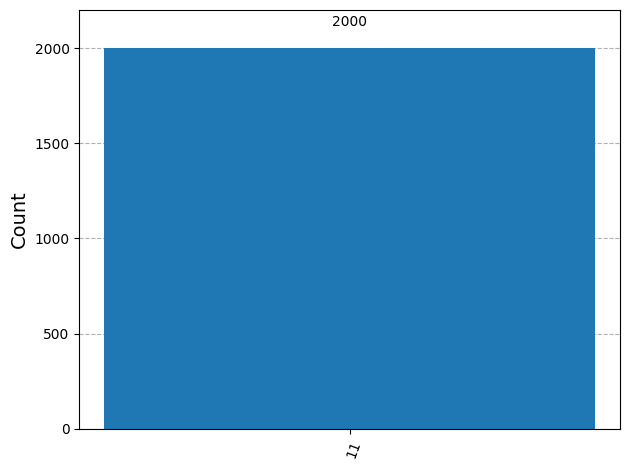


=== CH with control prepared as |1> ===
Statevector (before measurement):
Statevector([0.        +0.j, 0.70710678+0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


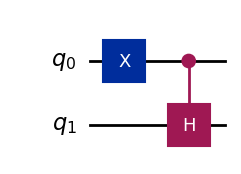

Counts: {'11': 1017, '01': 983}


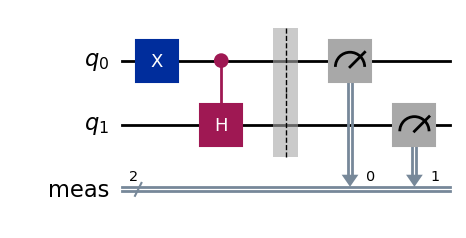

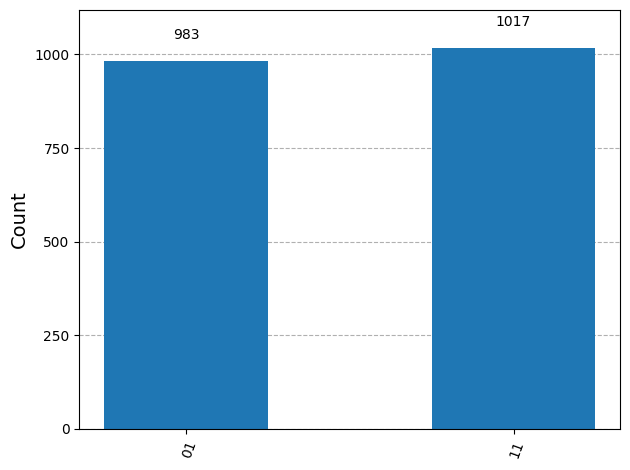

{'11': 1017, '01': 983}

In [42]:
qc = QuantumCircuit(2, name='CY')
qc.x(0)       # control = 1
qc.cy(0, 1)   # apply Y to target
demo(qc, 'CY with control prepared as |1>')

qc = QuantumCircuit(2, name='CH')
qc.x(0)       # control = 1
qc.ch(0, 1)   # apply H to target
demo(qc, 'CH with control prepared as |1>')

### Controlled phase (CP)
Applies a phase e^{iλ} to the |11⟩ component.


=== CP(pi/2) on |++> ===
Statevector (before measurement):
Statevector([5.000000e-01+0.j , 5.000000e-01+0.j , 5.000000e-01+0.j ,
             3.061617e-17+0.5j],
            dims=(2, 2))


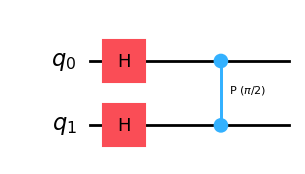

Counts: {'10': 524, '00': 501, '11': 476, '01': 499}


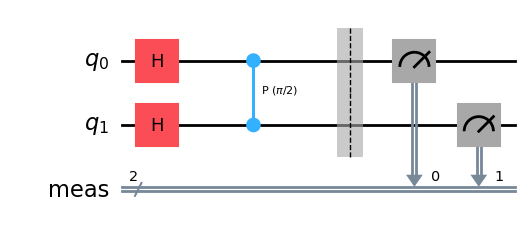

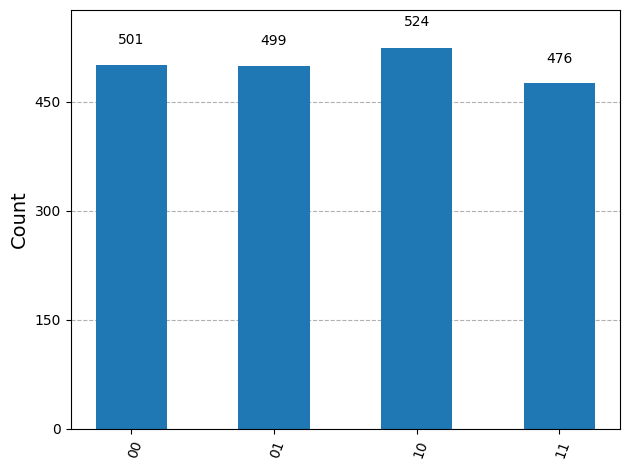

{'10': 524, '00': 501, '11': 476, '01': 499}

In [43]:
qc = QuantumCircuit(2, name='CP')
qc.h(0)
qc.h(1)
qc.cp(np.pi/2, 0, 1)
demo(qc, 'CP(pi/2) on |++>')

### SWAP
Swaps the states of two qubits.


=== SWAP: |01> -> |10> ===
Statevector (before measurement):
Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


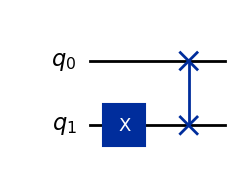

Counts: {'01': 2000}


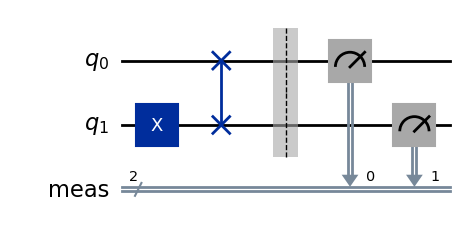

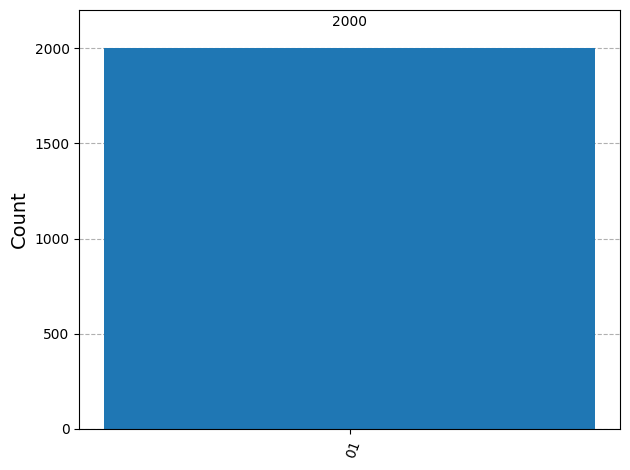

{'01': 2000}

In [44]:
qc = QuantumCircuit(2, name='SWAP')
qc.x(1)        # prepare |01>
qc.swap(0, 1)   # becomes |10>
demo(qc, 'SWAP: |01> -> |10>', show_statevector=True)

### Toffoli (CCX)
A 3-qubit controlled-controlled-X. Flips the target if **both** controls are 1.


=== CCX (Toffoli): controls=11 flips target ===
Statevector (before measurement):
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             1.+0.j],
            dims=(2, 2, 2))


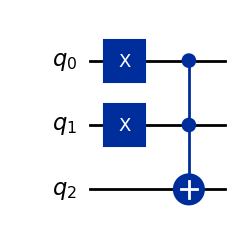

Counts: {'111': 2000}


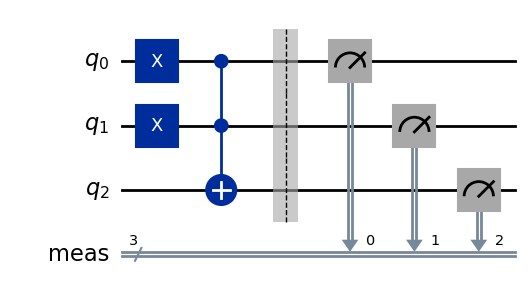

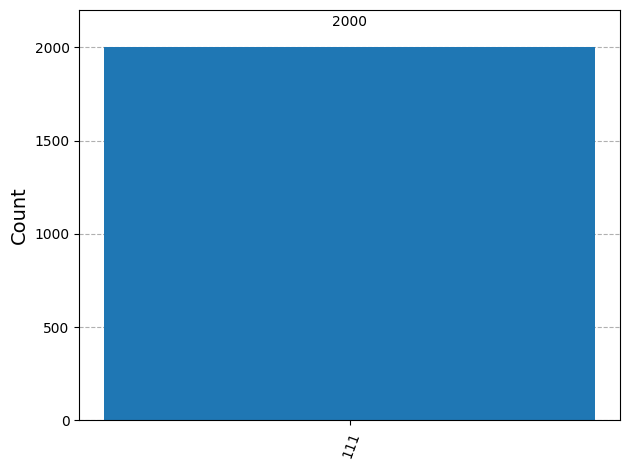

{'111': 2000}

In [45]:
qc = QuantumCircuit(3, name='CCX')
qc.x(0)
qc.x(1)         # controls = 1
qc.ccx(0, 1, 2)  # target flips
demo(qc, 'CCX (Toffoli): controls=11 flips target')

### Controlled-SWAP (CSWAP / Fredkin)
Swaps two target qubits if the control qubit is 1.


=== CSWAP: with control=1 swaps the last two qubits ===
Statevector (before measurement):
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


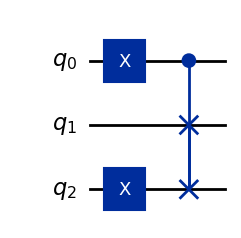

Counts: {'011': 2000}


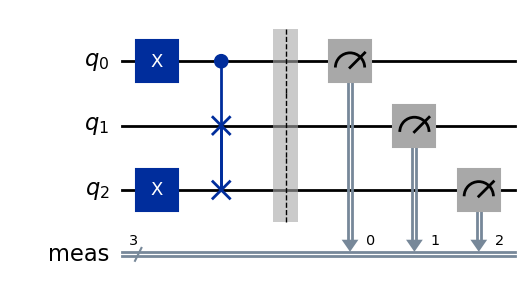

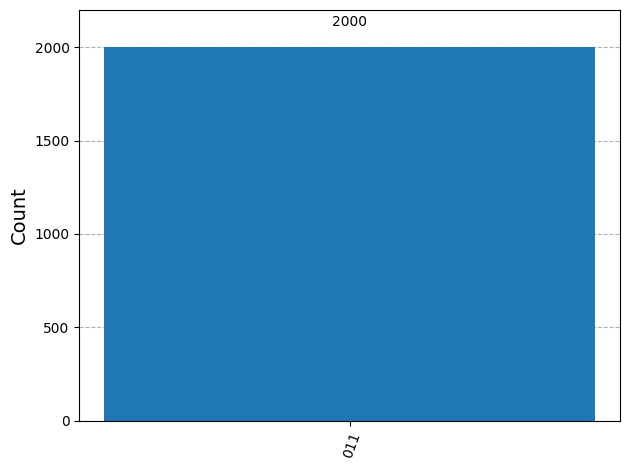

{'011': 2000}

In [46]:
qc = QuantumCircuit(3, name='CSWAP')
qc.x(0)      # control=1
qc.x(2)      # prepare |101> (targets are qubit1=0, qubit2=1)
qc.cswap(0, 1, 2)
demo(qc, 'CSWAP: with control=1 swaps the last two qubits')

## Non-unitary operations (not gates)
Measurement and reset are essential circuit operations, but they are **not** unitary gates.

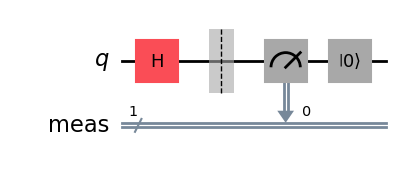

Counts: {'0': 1020, '1': 980}


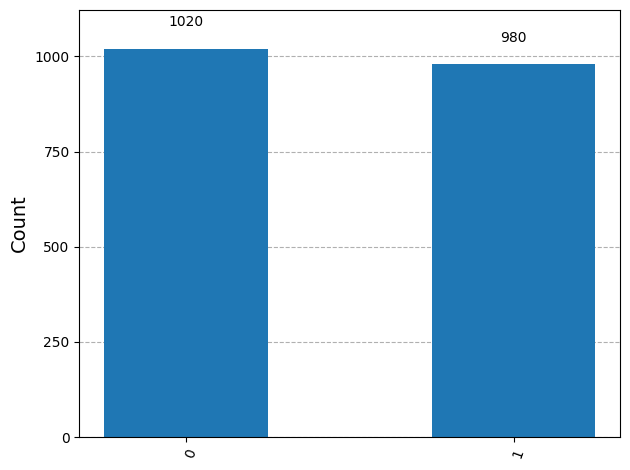

In [47]:
qc = QuantumCircuit(1, name='Measure + Reset')
qc.h(0)
qc.measure_all()
# Reset forces the qubit back to |0> (shown here after measurement for demonstration)
qc.reset(0)
display(qc.draw('mpl'))
tqc = transpile(qc, simulator)
result = simulator.run(tqc, shots=2000).result()
counts = result.get_counts()
print('Counts:', counts)
display(plot_histogram(counts))

## Quantum Teleportation (Alice → Bob)

Goal: teleport an *unknown* single-qubit state |ψ⟩ from **Alice** to **Bob** using:

- 1 shared entangled Bell pair (between Alice and Bob)
- 2 classical bits sent from Alice to Bob
- Conditional corrections (X/Z) applied by Bob

Qubit roles in the circuit:
- q0: Alice’s message qubit (the state |ψ⟩ to teleport)
- q1: Alice’s half of the Bell pair
- q2: Bob’s half of the Bell pair (receives |ψ⟩)

Input |ψ⟩ statevector: Statevector([0.74317106-0.50843068j, 0.35899255+0.24560002j],
            dims=(2,))
Fidelity (unitary/deferred check) between Bob and input: 1.000000


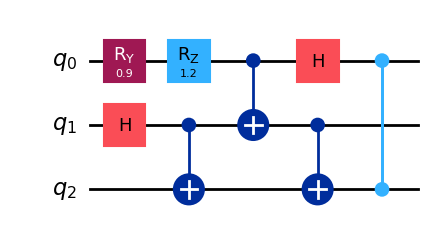

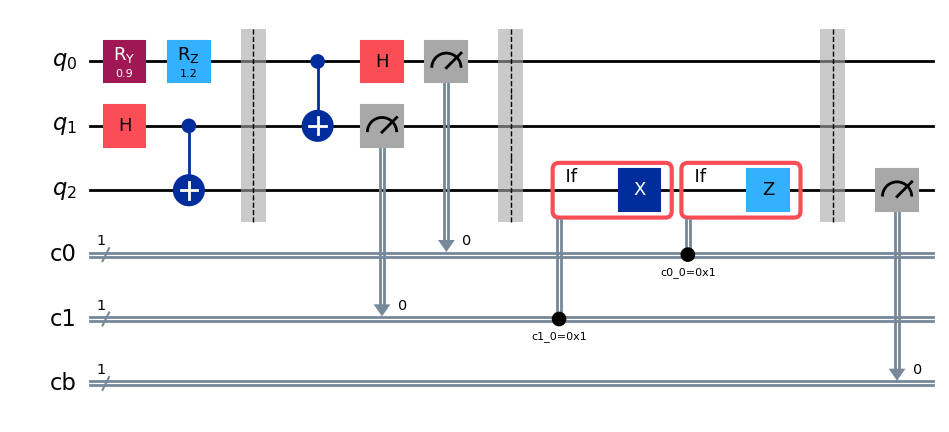

Raw counts (all classical bits): {'0 0 1': 781, '0 1 1': 849, '1 0 1': 193, '1 1 0': 180, '0 0 0': 812, '0 1 0': 822, '1 1 1': 183, '1 0 0': 180}
Bob counts (Z basis only): {'0': 3264, '1': 736}


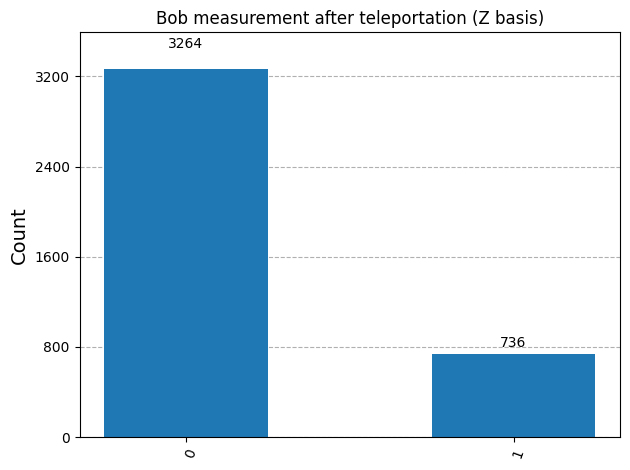

Expected P(0)=0.8108, P(1)=0.1892
Bob counts (X basis): {'1': 1414, '0': 2586}


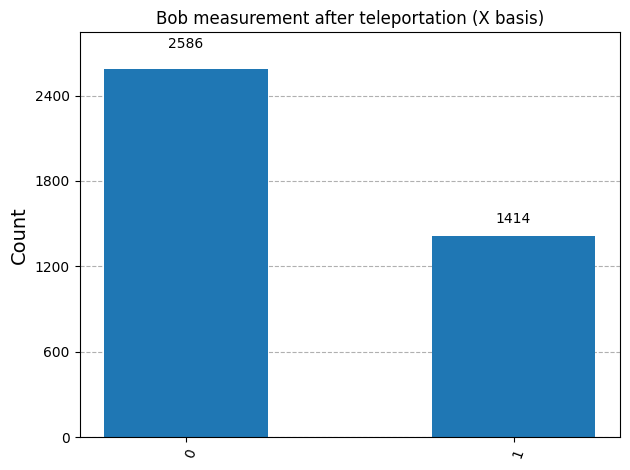

In [48]:
# Quantum Teleportation: implementation + verification
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.result import marginal_counts
import numpy as np
from IPython.display import display

# Choose an arbitrary single-qubit state |ψ⟩ to teleport (has amplitude + phase)
theta = 0.9  # rotation around Y
phi = 1.2    # rotation around Z (phase)

# Build |ψ⟩ on a single qubit (for reference)
psi_prep = QuantumCircuit(1, name='|ψ⟩ prep')
psi_prep.ry(theta, 0)
psi_prep.rz(phi, 0)
psi = Statevector.from_instruction(psi_prep)
print('Input |ψ⟩ statevector:', psi)

# --- 1) Verification via deferred measurement (purely unitary circuit) ---
# This uses the deferred-measurement principle to avoid mid-circuit measurement,
# so we can verify with an exact statevector simulation.
qc_unitary = QuantumCircuit(3, name='Teleport (unitary check)')
qc_unitary.ry(theta, 0)
qc_unitary.rz(phi, 0)

# Create Bell pair between q1 (Alice) and q2 (Bob)
qc_unitary.h(1)
qc_unitary.cx(1, 2)

# Alice's Bell-basis measurement steps (but we do NOT measure here)
qc_unitary.cx(0, 1)
qc_unitary.h(0)

# Bob's corrections, done coherently instead of classically (deferred measurement)
qc_unitary.cx(1, 2)  # corresponds to X correction controlled by Alice's 2nd bit
qc_unitary.cz(0, 2)  # corresponds to Z correction controlled by Alice's 1st bit

sv = Statevector.from_instruction(qc_unitary)
rho_bob = partial_trace(sv, [0, 1])  # trace out Alice's qubits
fid = state_fidelity(rho_bob, psi)
print(f'Fidelity (unitary/deferred check) between Bob and input: {fid:.6f}')
display(qc_unitary.draw('mpl'))

# --- 2) Actual teleportation circuit (measurements + classical communication) ---
q = QuantumRegister(3, 'q')
c0 = ClassicalRegister(1, 'c0')  # Alice measurement bit 0 (from q0)
c1 = ClassicalRegister(1, 'c1')  # Alice measurement bit 1 (from q1)
cb = ClassicalRegister(1, 'cb')  # Bob measurement (for checking)
qc = QuantumCircuit(q, c0, c1, cb, name='Teleport (Alice/Bob)')

# (A) Alice prepares the unknown state on q0
qc.ry(theta, q[0])
qc.rz(phi, q[0])

# (B) Create shared entanglement between Alice (q1) and Bob (q2)
qc.h(q[1])
qc.cx(q[1], q[2])
qc.barrier()

# (C) Alice performs Bell-basis measurement on (q0, q1)
qc.cx(q[0], q[1])
qc.h(q[0])
qc.measure(q[0], c0[0])
qc.measure(q[1], c1[0])
qc.barrier()

# (D) Bob applies corrections based on Alice's two classical bits
with qc.if_test((c1[0], 1)):
    qc.x(q[2])
with qc.if_test((c0[0], 1)):
    qc.z(q[2])
qc.barrier()

# Check by measuring Bob in Z basis
qc.measure(q[2], cb[0])
display(qc.draw('mpl'))

tqc = transpile(qc, simulator)
res = simulator.run(tqc, shots=4000).result()
counts = res.get_counts()
print('Raw counts (all classical bits):', counts)

# Extract Bob-only counts (classical bit index 2 because clbits are [c0[0], c1[0], cb[0]])
bob_counts = marginal_counts(counts, indices=[2])
print('Bob counts (Z basis only):', bob_counts)
display(plot_histogram(bob_counts, title='Bob measurement after teleportation (Z basis)'))

# Compare with the expected Z-basis probabilities of |ψ⟩
p0, p1 = psi.probabilities()  # [P(0), P(1)]
print(f'Expected P(0)={p0:.4f}, P(1)={p1:.4f}')

# Optional: measure Bob in X basis too (detects phase information)
qc_x = QuantumCircuit(q, c0, c1, cb, name='Teleport + X-basis check')
qc_x.ry(theta, q[0])
qc_x.rz(phi, q[0])
qc_x.h(q[1])
qc_x.cx(q[1], q[2])
qc_x.cx(q[0], q[1])
qc_x.h(q[0])
qc_x.measure(q[0], c0[0])
qc_x.measure(q[1], c1[0])
with qc_x.if_test((c1[0], 1)):
    qc_x.x(q[2])
with qc_x.if_test((c0[0], 1)):
    qc_x.z(q[2])
qc_x.h(q[2])              # rotate X basis -> Z basis
qc_x.measure(q[2], cb[0])

tqc_x = transpile(qc_x, simulator)
res_x = simulator.run(tqc_x, shots=4000).result()
counts_x = res_x.get_counts()
bob_counts_x = marginal_counts(counts_x, indices=[2])
print('Bob counts (X basis):', bob_counts_x)
display(plot_histogram(bob_counts_x, title='Bob measurement after teleportation (X basis)'))

## Deutsch–Jozsa Algorithm

Problem: given an oracle for a Boolean function f(x) with promise that it is either:
- **Constant**: f(x) is the same for all x (all 0 or all 1), or
- **Balanced**: f(x)=0 for exactly half of inputs and 1 for the other half.

Deutsch–Jozsa determines **constant vs balanced with one oracle call** (ideal/noiseless case).

**Result:** after running the algorithm, measure the n input qubits:
- if the outcome is **all zeros** ("0...0") → f is constant
- otherwise → f is balanced

Below we show two example oracles for n=3:
- Constant oracle f(x)=0 (does nothing)
- Balanced oracle f(x)=x₀ (controlled-NOT from the first input qubit to the ancilla)

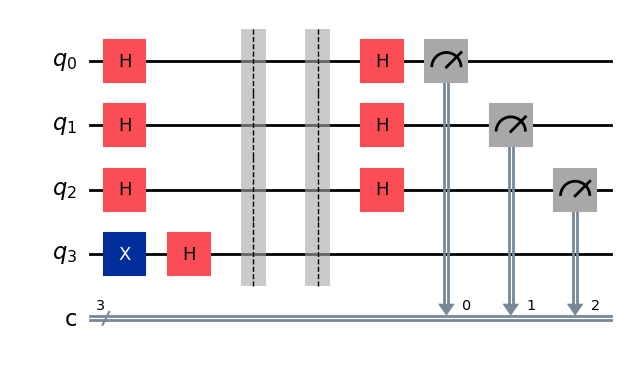

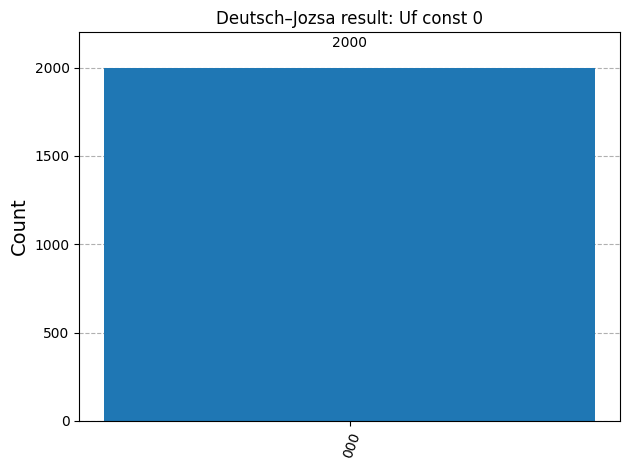

          Uf const 0 | P(0...0) ≈ 1.000 | counts={'000': 2000}


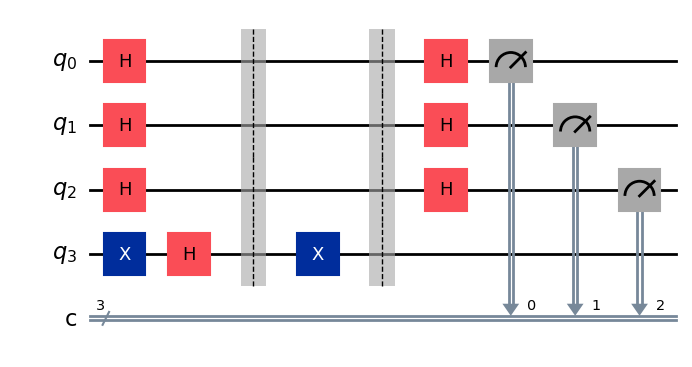

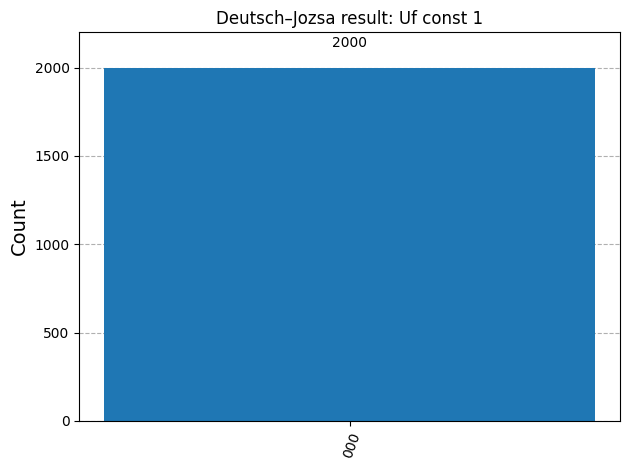

          Uf const 1 | P(0...0) ≈ 1.000 | counts={'000': 2000}


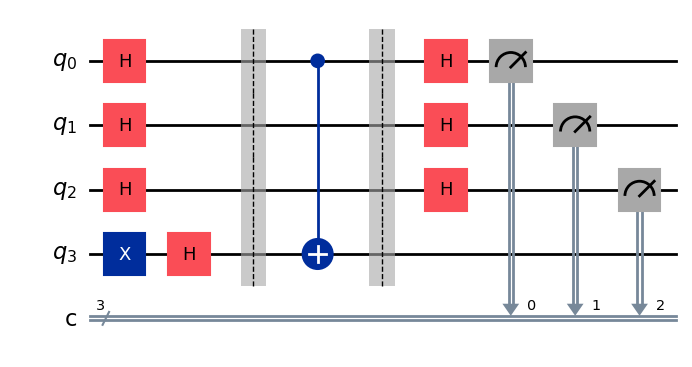

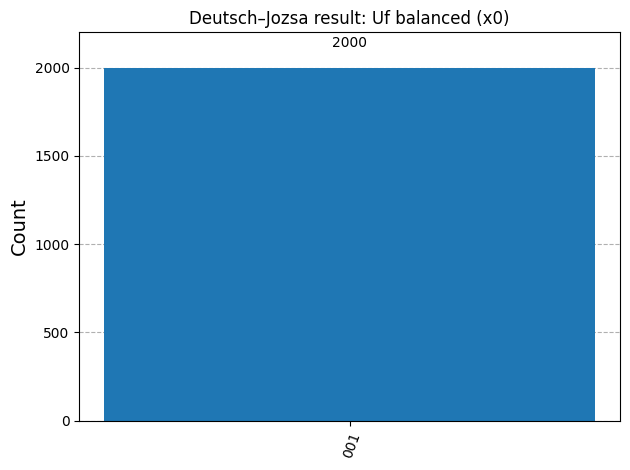

    Uf balanced (x0) | P(0...0) ≈ 0.000 | counts={'001': 2000}


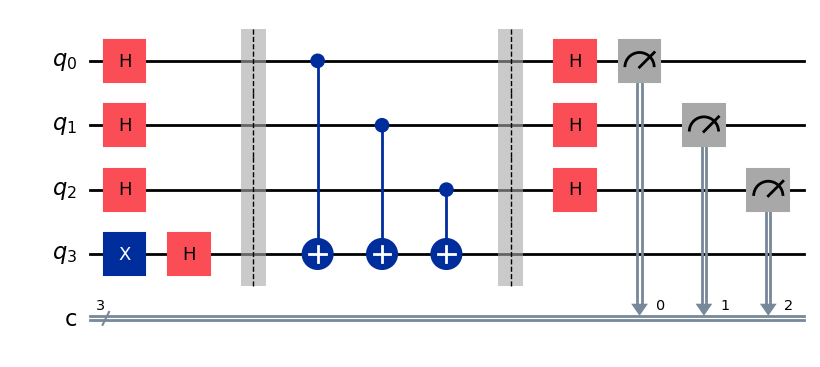

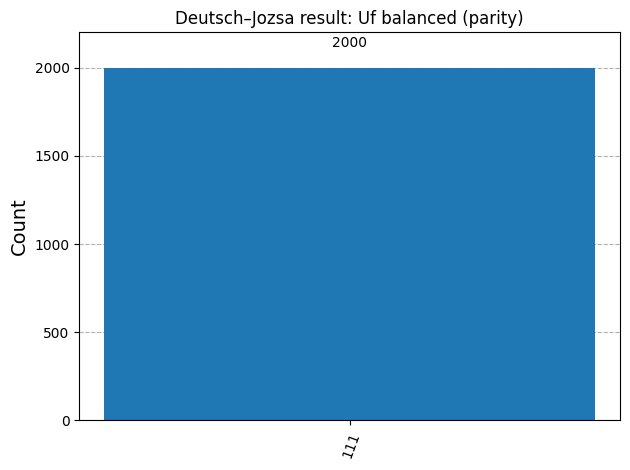

Uf balanced (parity) | P(0...0) ≈ 0.000 | counts={'111': 2000}


In [49]:
# Deutsch–Jozsa: circuit builder + example oracles
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from IPython.display import display
import numpy as np

def deutsch_jozsa_circuit(oracle: QuantumCircuit, n: int) -> QuantumCircuit:
    """Return a Deutsch–Jozsa circuit for n input qubits using the provided oracle Uf.
    
    Oracle convention (n+1 qubits): |x, y> -> |x, y xor f(x)>.
    """
    if oracle.num_qubits != n + 1:
        raise ValueError(f"Oracle must have {n+1} qubits (got {oracle.num_qubits}).")
    
    q = QuantumRegister(n + 1, 'q')  # last qubit is ancilla
    c = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(q, c, name=f'DJ n={n}')
    anc = n
    
    # Prepare |0...0>|1> then Hadamards to get |+...+>|->
    qc.x(q[anc])
    qc.h(q[anc])
    qc.h(q[0:n])
    qc.barrier()
    
    # Apply oracle Uf
    qc.compose(oracle, qubits=q, inplace=True)
    qc.barrier()
    
    # Interference step
    qc.h(q[0:n])
    qc.measure(q[0:n], c)
    return qc

# --- Example oracles for n=3 ---
n = 3

# Constant oracle f(x)=0: do nothing to ancilla (identity)
oracle_const0 = QuantumCircuit(n + 1, name='Uf const 0')

# Constant oracle f(x)=1: flip ancilla for all x (X on ancilla)
oracle_const1 = QuantumCircuit(n + 1, name='Uf const 1')
oracle_const1.x(n)

# Balanced oracle: f(x) = x0 (first input bit)
oracle_balanced_x0 = QuantumCircuit(n + 1, name='Uf balanced (x0)')
oracle_balanced_x0.cx(0, n)

# Another balanced oracle: f(x) = x0 XOR x1 XOR x2 (parity)
oracle_balanced_parity = QuantumCircuit(n + 1, name='Uf balanced (parity)')
for i in range(n):
    oracle_balanced_parity.cx(i, n)

oracles = [oracle_const0, oracle_const1, oracle_balanced_x0, oracle_balanced_parity]

def run_dj(oracle: QuantumCircuit, shots: int = 2000):
    qc = deutsch_jozsa_circuit(oracle, n=n)
    display(qc.draw('mpl'))
    tqc = transpile(qc, simulator)
    res = simulator.run(tqc, shots=shots).result()
    counts = res.get_counts()
    display(plot_histogram(counts, title=f"Deutsch–Jozsa result: {oracle.name}"))
    return counts

for oracle in oracles:
    counts = run_dj(oracle, shots=2000)
    # In ideal DJ: constant -> always '000' ; balanced -> never '000'
    p000 = counts.get('0' * n, 0) / 2000
    print(f"{oracle.name:>20} | P(0...0) ≈ {p000:.3f} | counts={counts}")

## Bernstein–Vazirani Algorithm

Problem: you’re given an oracle for a Boolean function of the form:

$$ f(x) = s \cdot x \oplus b $$

where $s$ is a hidden *n-bit* string, $b \in \{0,1\}$ is a constant, and $s \cdot x$ is the bitwise inner product mod 2.

Goal: find the secret string $s$ using **one** oracle query (ideal/noiseless case).

**Oracle convention** (same as Deutsch–Jozsa):

$$ U_f\,|x, y\rangle = |x,\, y \oplus f(x)\rangle $$

**Result:** after the final Hadamards, measuring the input register returns the secret string $s$ with probability 1.

**Note on bit order (Qiskit):** when you measure qubits `q[0..n-1]` into classical bits `c[0..n-1]`, the printed bitstring is shown as `c[n-1]...c[0]`. So the displayed key in `counts` is the reverse of the `q0..q(n-1)` order.

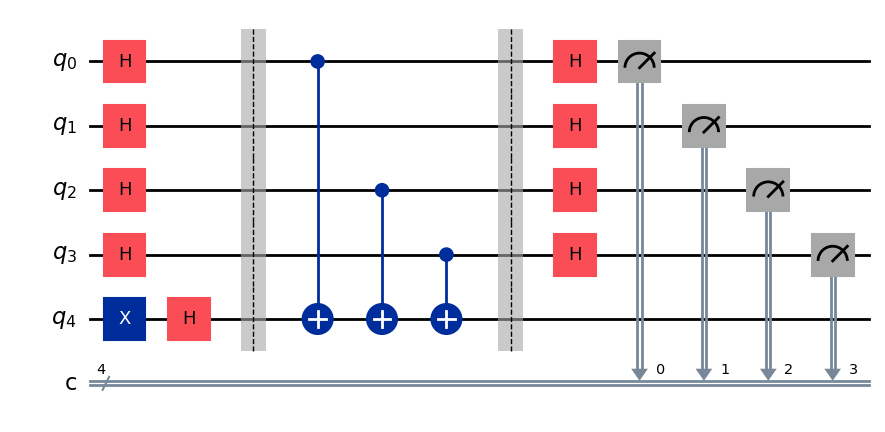

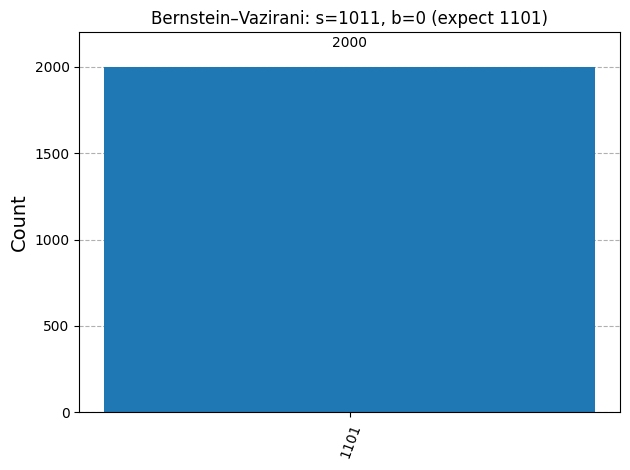

secret bits (q0..q(n-1)): 1011
expected counts key (c[n-1]..c0): 1101
counts: {'1101': 2000}


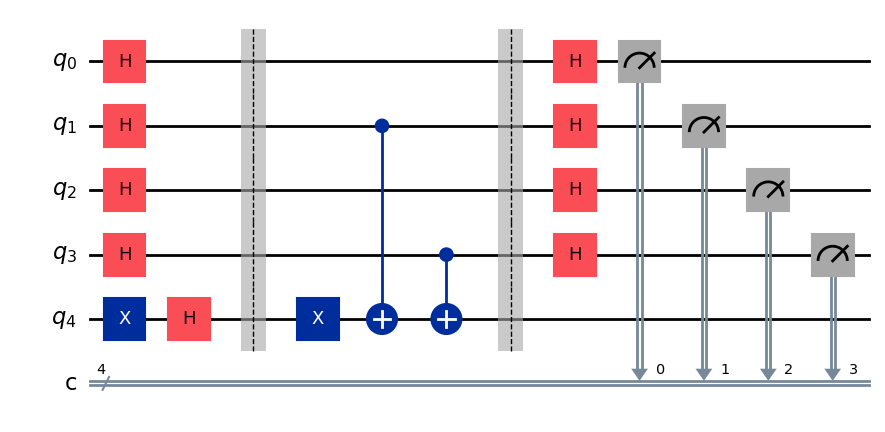

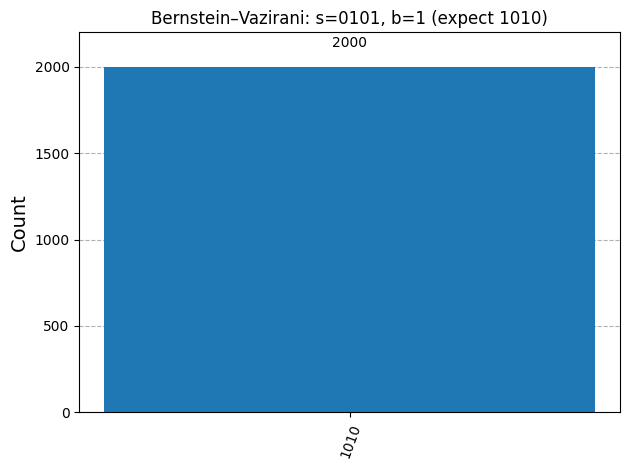

secret bits (q0..q(n-1)): 0101
expected counts key (c[n-1]..c0): 1010
counts: {'1010': 2000}


{'1010': 2000}

In [ ]:
# Bernstein–Vazirani: circuit builder + example oracles
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from IPython.display import display

def bv_oracle(secret_bits_q0_to_qn: str, b: int = 0) -> QuantumCircuit:
    """Build a Bernstein-Vazirani oracle Uf on (n + 1) qubits.

    secret_bits_q0_to_qn is a bitstring where index i corresponds to input qubit q[i].
    Oracle convention: |x, y> -> |x, y xor (s·x xor b)>.

    Note: if the ancilla is prepared in |->, the constant b only contributes a global phase,
    so it does not change measurement results on the input register.
    """
    if any(ch not in "01" for ch in secret_bits_q0_to_qn):
        raise ValueError("secret_bits must be a string of '0'/'1'.")
    if b not in (0, 1):
        raise ValueError("b must be 0 or 1.")
    n = len(secret_bits_q0_to_qn)
    anc = n
    oracle = QuantumCircuit(n + 1, name=f"Uf BV s={secret_bits_q0_to_qn}, b={b}")
    if b == 1:
        oracle.x(anc)
    for i, bit in enumerate(secret_bits_q0_to_qn):
        if bit == "1":
            oracle.cx(i, anc)
    return oracle


def bernstein_vazirani_circuit(secret_bits_q0_to_qn: str, b: int = 0) -> QuantumCircuit:
    """Return a Bernstein-Vazirani circuit that recovers secret_bits in one query."""
    n = len(secret_bits_q0_to_qn)
    q = QuantumRegister(n + 1, 'q')  # last qubit is ancilla
    c = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(q, c, name=f"BV n={n}")
    anc = n

    # Prepare |0...0>|1> then H to get |+...+>|->
    qc.x(q[anc])
    qc.h(q[anc])
    qc.h(q[0:n])
    qc.barrier()

    # Oracle
    oracle = bv_oracle(secret_bits_q0_to_qn, b=b)
    qc.compose(oracle, qubits=q, inplace=True)
    qc.barrier()

    # Interference reveals s
    qc.h(q[0:n])
    qc.measure(q[0:n], c)
    return qc


def run_bv(secret_bits_q0_to_qn: str, b: int = 0, shots: int = 2000):
    qc = bernstein_vazirani_circuit(secret_bits_q0_to_qn, b=b)
    display(qc.draw('mpl'))
    tqc = transpile(qc, simulator)
    res = simulator.run(tqc, shots=shots).result()
    counts = res.get_counts()

    # Qiskit prints bitstrings as c[n-1]...c[0], so reverse for the expected displayed key.
    expected_key = secret_bits_q0_to_qn[::-1]
    display(plot_histogram(counts, title=f"Bernstein-Vazirani: s={secret_bits_q0_to_qn}, b={b} (expect {expected_key})"))
    print("secret bits (q0..q(n-1)):", secret_bits_q0_to_qn)
    print("expected counts key (c[n-1]..c0):", expected_key)
    print("counts:", counts)
    return counts


# --- Examples ---
run_bv("1011", b=0, shots=2000)
run_bv("0101", b=1, shots=2000)  # b doesn't affect the recovered s when using |-> ancilla

## Simon’s Algorithm

Problem: you’re given an oracle for a function $f:\{0,1\}^n \to \{0,1\}^n$ with the promise that there exists a non‑zero secret string $s\in\{0,1\}^n$ such that:

- $f(x) = f(x \oplus s)$ for all $x$ (so $f$ is **2-to-1**)

Goal: find the hidden string $s$ with $O(n)$ oracle queries (ideal/noiseless case).

**Oracle convention** (same as Deutsch–Jozsa / BV):

$$ U_f\,|x, y\rangle = |x,\, y \oplus f(x)\rangle $$

**Key idea:** each run of Simon’s circuit produces a bitstring $y$ such that:

$$ y \cdot s = 0 \pmod 2 $$

After collecting about $n-1$ linearly independent such equations, solve the linear system over GF(2) to recover $s$.

**Note on bit order (Qiskit):** measurement keys are printed as `c[n-1]...c[0]`. If we measure `q[0..n-1]` into `c[0..n-1]`, the displayed bitstring is reversed relative to `q0..q(n-1)`.

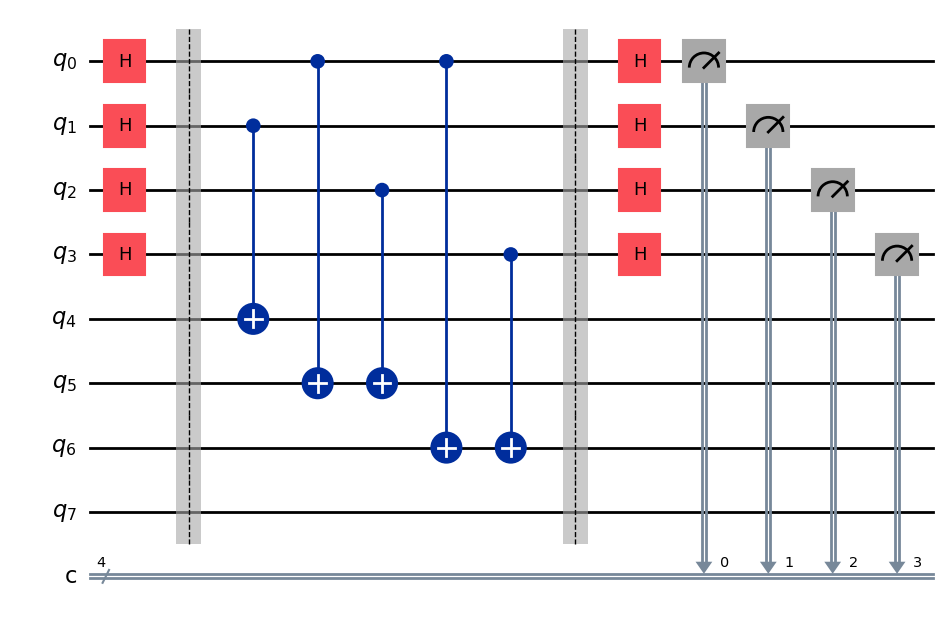

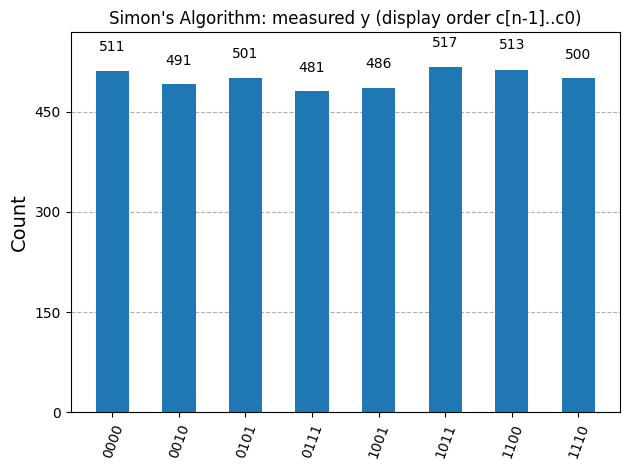

Secret s (q0..q(n-1)): 1011
Recovered s (q0..q(n-1)): 1011
Collected y equations (q0..q(n-1)), y·s=0: ['1101', '0011', '1010']


('1011',
 {'0010': 491,
  '1011': 517,
  '0000': 511,
  '1110': 500,
  '0101': 501,
  '1001': 486,
  '1100': 513,
  '0111': 481})

In [51]:
# Simon's Algorithm: oracle construction + solving for the hidden string s
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from IPython.display import display
import numpy as np

def _parity(x: int) -> int:
    # parity of integer bitcount
    return bin(x).count('1') & 1


def _bitstring_q0_to_qn_to_mask(bits_q0_to_qn: str) -> int:
    """Convert bitstring ordered as q0..q(n-1) into an integer mask with bit i -> qi."""
    mask = 0
    for i, ch in enumerate(bits_q0_to_qn):
        if ch == '1':
            mask |= (1 << i)
        elif ch != '0':
            raise ValueError("Bitstring must contain only '0'/'1'.")
    return mask


def _mask_to_bitstring_q0_to_qn(mask: int, n: int) -> str:
    return ''.join('1' if (mask >> i) & 1 else '0' for i in range(n))


def _add_to_gf2_basis(basis: list[int], v: int) -> bool:
    """Try to add v to a GF(2) row basis (bitmask representation). Returns True if independent."""
    x = v
    for b in basis:
        x = min(x, x ^ b)  # keep a reduced representative
    if x == 0:
        return False
    # Insert while keeping basis roughly ordered by highest set bit (not strictly required)
    basis.append(x)
    basis.sort(reverse=True)
    return True


def _rref_gf2(rows: list[int], n: int) -> tuple[list[int], list[int]]:
    """Reduced row echelon form over GF(2). Returns (rows_rref, pivots)."""
    rows = [r & ((1 << n) - 1) for r in rows if r != 0]
    pivots: list[int] = []
    r = 0
    for col in range(n):
        # Find pivot row with bit col set
        pivot = None
        for i in range(r, len(rows)):
            if (rows[i] >> col) & 1:
                pivot = i
                break
        if pivot is None:
            continue
        rows[r], rows[pivot] = rows[pivot], rows[r]
        pivots.append(col)
        # Eliminate this column from all other rows
        for i in range(len(rows)):
            if i != r and ((rows[i] >> col) & 1):
                rows[i] ^= rows[r]
        r += 1
        if r == len(rows):
            break
    return rows, pivots


def _nullspace_basis_gf2(rows: list[int], n: int) -> list[int]:
    """Return a basis for {x : rows * x = 0} over GF(2), using bitmask representation."""
    rows_rref, pivots = _rref_gf2(rows, n)
    pivot_set = set(pivots)
    free_vars = [i for i in range(n) if i not in pivot_set]
    basis: list[int] = []
    for f in free_vars:
        vec = 1 << f
        for row_mask, pivot_col in zip(rows_rref, pivots):
            if (row_mask >> f) & 1:
                vec ^= (1 << pivot_col)
        basis.append(vec)
    return [v for v in basis if v != 0]


def simon_linear_oracle_for_secret(secret_bits_q0_to_qn: str) -> tuple[QuantumCircuit, list[int]]:
    """Create a Simon oracle Uf implementing a linear 2-to-1 function with hidden period s.

    We build f(x) = M x over GF(2), where M has rank n-1 and M s = 0.
    This guarantees f(x) = f(x xor s).
    Returns (oracle_circuit_on_2n_qubits, row_masks_of_M).
    """
    if any(ch not in '01' for ch in secret_bits_q0_to_qn):
        raise ValueError("secret_bits must be a string of '0'/'1'.")
    n = len(secret_bits_q0_to_qn)
    s_mask = _bitstring_q0_to_qn_to_mask(secret_bits_q0_to_qn)
    if s_mask == 0:
        raise ValueError("Simon secret s must be non-zero.")

    # Choose n-1 independent row vectors orthogonal to s (row · s = 0).
    basis: list[int] = []
    rows: list[int] = []
    for v in range(1, 1 << n):
        if _parity(v & s_mask) == 0:
            if _add_to_gf2_basis(basis, v):
                rows.append(v)
                if len(rows) == n - 1:
                    break
    if len(rows) != n - 1:
        raise RuntimeError("Failed to construct rank n-1 matrix orthogonal to s (unexpected).")

    # Make M an n×n matrix by adding a zero row (keeps rank n-1, output still n bits).
    row_masks = rows + [0]
    oracle = QuantumCircuit(2 * n, name=f"Uf Simon s={secret_bits_q0_to_qn}")
    # Output register starts at qubit index n
    for out_j, row in enumerate(row_masks):
        for i in range(n):
            if (row >> i) & 1:
                oracle.cx(i, n + out_j)
    return oracle, row_masks


def simon_circuit(oracle: QuantumCircuit, n: int) -> QuantumCircuit:
    """Build Simon's algorithm circuit for an oracle on 2n qubits."""
    if oracle.num_qubits != 2 * n:
        raise ValueError(f"Oracle must act on 2n={2*n} qubits (got {oracle.num_qubits}).")

    q = QuantumRegister(2 * n, 'q')
    c = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(q, c, name=f"Simon n={n}")
    inp = list(range(n))
    qc.h(inp)
    qc.barrier()
    qc.compose(oracle, qubits=q, inplace=True)
    qc.barrier()
    qc.h(inp)
    qc.measure(inp, c)
    return qc


def recover_s_from_counts(counts: dict, n: int) -> tuple[str, list[str]]:
    """Recover s (q0..q(n-1) order) from Simon measurement counts over the input register."""
    equations: list[int] = []
    eq_basis: list[int] = []
    ys_collected: list[str] = []
    # Prefer higher-probability outcomes first
    for key, _ in sorted(counts.items(), key=lambda kv: kv[1], reverse=True):
        y_q0_to_qn = key[::-1]  # convert displayed c[n-1]..c0 to q0..q(n-1)
        y_mask = _bitstring_q0_to_qn_to_mask(y_q0_to_qn)
        if y_mask == 0:
            continue
        if _add_to_gf2_basis(eq_basis, y_mask):
            equations.append(y_mask)
            ys_collected.append(y_q0_to_qn)
        if len(equations) >= n - 1:
            break

    null_basis = _nullspace_basis_gf2(equations, n)
    if not null_basis:
        return "0" * n, ys_collected
    # In the promised case, nullspace is span{s} (dimension 1). Pick the first basis vector.
    s_mask = null_basis[0]
    return _mask_to_bitstring_q0_to_qn(s_mask, n), ys_collected


def run_simon(secret_s: str, shots: int = 4000, max_rounds: int = 5):
    n = len(secret_s)
    oracle, _ = simon_linear_oracle_for_secret(secret_s)
    qc = simon_circuit(oracle, n)
    display(qc.draw('mpl'))

    all_counts = {}
    for _ in range(max_rounds):
        tqc = transpile(qc, simulator)
        res = simulator.run(tqc, shots=shots).result()
        counts = res.get_counts()
        # merge counts
        for k, v in counts.items():
            all_counts[k] = all_counts.get(k, 0) + v
        found_s, ys = recover_s_from_counts(all_counts, n)
        # Stop once we have enough independent equations and found non-zero s
        if found_s != "0" * n and len(ys) >= n - 1:
            break

    display(plot_histogram(all_counts, title=f"Simon's Algorithm: measured y (display order c[n-1]..c0)"))
    found_s, ys = recover_s_from_counts(all_counts, n)
    print("Secret s (q0..q(n-1)):", secret_s)
    print("Recovered s (q0..q(n-1)):", found_s)
    print("Collected y equations (q0..q(n-1)), y·s=0:", ys)
    return found_s, all_counts


# --- Example ---
run_simon(secret_s="1011", shots=4000)

# Grover Search Algorithm

Goal: find a *marked* basis state $|w\rangle$ among $N=2^n$ possibilities using amplitude amplification.

Grover repeatedly applies:
- an **oracle** that flips the phase of the marked state: $|w\rangle \mapsto -|w\rangle$
- a **diffusion (inversion-about-mean)** operator that amplifies the marked amplitude

After about
$$ r \approx \left\lfloor \frac{\pi}{4}\sqrt{N}\right\rfloor $$
iterations, measuring returns the marked state with high probability (ideal/noiseless case).

**Note on bit order (Qiskit):** if you measure `q[0..n-1]` into classical bits `c[0..n-1]`, the key printed in `counts` is displayed as `c[n-1]...c[0]` (reversed vs `q0..q(n-1)`).

Marked state (q0..q(n-1)) = 101
Expected highest-probability counts key (c[n-1]..c0) = 101
Grover iterations used r = 2


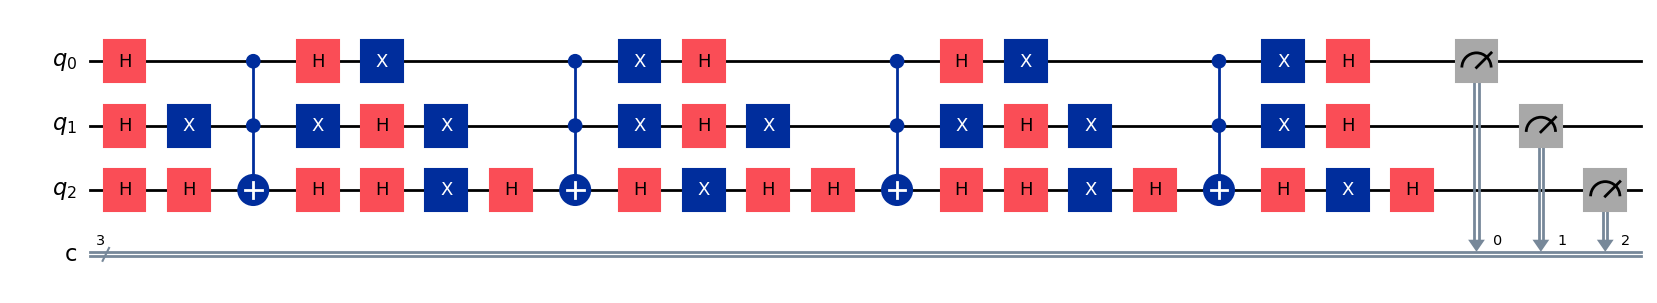

Counts: {'101': 1902, '100': 14, '110': 17, '011': 12, '001': 20, '000': 9, '111': 16, '010': 10}


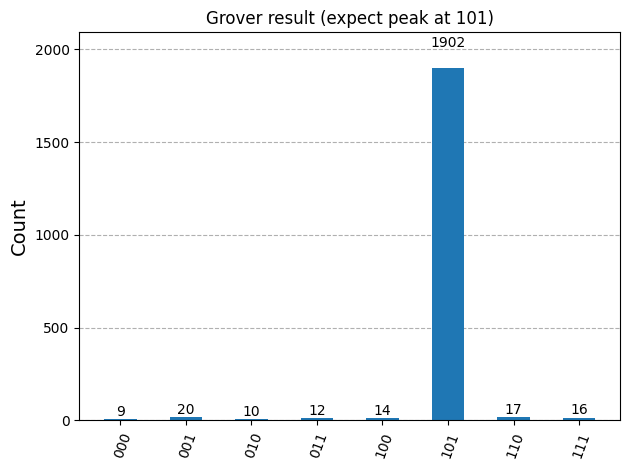

In [52]:
# Grover: oracle + diffuser + example run
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from IPython.display import display
import numpy as np

def apply_phase_oracle_for_marked(qc: QuantumCircuit, marked_q0_to_qn: str):
    """Flip the phase of |marked> (bitstring in q0..q(n-1) order)."""
    n = len(marked_q0_to_qn)
    if n == 0:
        raise ValueError("marked bitstring must be non-empty")
    if any(ch not in '01' for ch in marked_q0_to_qn):
        raise ValueError("marked bitstring must contain only '0'/'1'")

    # Map |marked> -> |11..1> using X on 0-bits, then apply multi-controlled Z, then unmap.
    zero_positions = [i for i, b in enumerate(marked_q0_to_qn) if b == '0']
    for i in zero_positions:
        qc.x(i)

    if n == 1:
        qc.z(0)
    else:
        # Multi-controlled Z using H–MCX–H on the last qubit.
        target = n - 1
        controls = list(range(n - 1))
        qc.h(target)
        qc.mcx(controls, target)
        qc.h(target)

    for i in zero_positions:
        qc.x(i)


def apply_diffuser(qc: QuantumCircuit, n: int):
    """Grover diffusion operator on the first n qubits."""
    qc.h(range(n))
    qc.x(range(n))
    if n == 1:
        qc.z(0)
    else:
        target = n - 1
        controls = list(range(n - 1))
        qc.h(target)
        qc.mcx(controls, target)
        qc.h(target)
    qc.x(range(n))
    qc.h(range(n))


def grover_circuit(marked_q0_to_qn: str, iterations: int | None = None) -> tuple[QuantumCircuit, int, str]:
    n = len(marked_q0_to_qn)
    q = QuantumRegister(n, 'q')
    c = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(q, c, name=f"Grover n={n}")

    # Start in uniform superposition
    qc.h(q)

    N = 2 ** n
    r_opt = int(np.floor((np.pi / 4) * np.sqrt(N)))
    r = r_opt if iterations is None else int(iterations)

    for _ in range(r):
        apply_phase_oracle_for_marked(qc, marked_q0_to_qn)
        apply_diffuser(qc, n)

    qc.measure(q, c)
    expected_key = marked_q0_to_qn[::-1]  # counts key is c[n-1]..c0
    return qc, r, expected_key


# --- Example: search for a marked state ---
marked = "101"   # this is in q0..q(n-1) order
qc, r, expected_key = grover_circuit(marked)
print(f"Marked state (q0..q(n-1)) = {marked}")
print(f"Expected highest-probability counts key (c[n-1]..c0) = {expected_key}")
print(f"Grover iterations used r = {r}")

display(qc.draw('mpl'))
tqc = transpile(qc, simulator)
res = simulator.run(tqc, shots=2000).result()
counts = res.get_counts()
print("Counts:", counts)
display(plot_histogram(counts, title=f"Grover result (expect peak at {expected_key})"))